## **Problem Statement**

### **Context**

AllLife Bank wants to focus on its credit card customer base in the next financial year. They have been advised by their marketing research team, that the penetration in the market can be improved. Based on this input, the Marketing team proposes to run personalized campaigns to target new customers as well as upsell to existing customers. Another insight from the market research was that the customers perceive the support services of the back poorly. Based on this, the Operations team wants to upgrade the service delivery model, to ensure that customer queries are resolved faster. The Head of Marketing and Head of Delivery both decide to reach out to the Data Science team for help

### **Objective**

To identify different segments in the existing customers, based on their spending patterns as well as past interaction with the bank, using clustering algorithms, and provide recommendations to the bank on how to better market to and service these customers.

### **Data Description**

The data provided is of various customers of a bank and their financial attributes like credit limit, the total number of credit cards the customer has, and different channels through which customers have contacted the bank for any queries (including visiting the bank, online, and through a call center).

### **Data Dictionary**

- Sl_No: Primary key of the records

- Customer Key: Customer identification number

- Average Credit Limit: Average credit limit of each customer for all credit cards

- Total credit cards: Total number of credit cards possessed by the customer

- Total visits bank: Total number of visits that the customer made (yearly) personally to the bank

- Total visits online: Total number of visits or online logins made by the customer (yearly)

- Total calls made: Total number of calls made by the customer to the bank or its customer service department (yearly)

### **Importing necessary libraries**

In [1]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# Libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

# For scaling the data
from sklearn.preprocessing import StandardScaler

# For clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# For elbow & silhouette visualization
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

# For hierarchical clustering
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# For PCA (dimensionality reduction)
from sklearn.decomposition import PCA

# To suppress warnings
import warnings
warnings.filterwarnings("ignore")


### **Loading the dataset**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
data = pd.read_excel('/content/drive/MyDrive/Credit Card Customer Data.xlsx')

#### **Displaying first 5 and last 5 rows of the dataset**

In [4]:
# Display first 5 rows
data.head()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3


In [5]:
# Display last 5 rows
data.tail()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
655,656,51108,99000,10,1,10,0
656,657,60732,84000,10,1,13,2
657,658,53834,145000,8,1,9,1
658,659,80655,172000,10,1,15,0
659,660,80150,167000,9,0,12,2


In [6]:
#Checking shape of dataset
data.shape

(660, 7)

**Creating a copy of original data**

In [7]:
# Creating a copy to protect original data
df = data.copy()

**Drop unnecessary columns**

In [8]:
# Dropping ID columns
df.drop(["Sl_No", "Customer Key"], axis=1, inplace=True)

**Check data types**

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Avg_Credit_Limit     660 non-null    int64
 1   Total_Credit_Cards   660 non-null    int64
 2   Total_visits_bank    660 non-null    int64
 3   Total_visits_online  660 non-null    int64
 4   Total_calls_made     660 non-null    int64
dtypes: int64(5)
memory usage: 25.9 KB


**Checking the missing values**

In [10]:
# checking for missing values
df.isnull().sum()

,0
Avg_Credit_Limit,0
Total_Credit_Cards,0
Total_visits_bank,0
Total_visits_online,0
Total_calls_made,0


**Checking for duplicates values**

In [11]:
# checking for duplicate values
df.duplicated().sum()

np.int64(11)

**Statistical summary**

In [12]:
df.describe()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
count,660.000000,660.000000,660.000000,660.000000,660.000000
mean,34574.242424,4.706061,2.403030,2.606061,3.583333
std,37625.487804,2.167835,1.631813,2.935724,2.865317
min,3000.000000,1.000000,0.000000,0.000000,0.000000
25%,10000.000000,3.000000,1.000000,1.000000,1.000000
50%,18000.000000,5.000000,2.000000,2.000000,3.000000
75%,48000.000000,6.000000,4.000000,4.000000,5.000000
max,200000.000000,10.000000,5.000000,15.000000,10.000000


**Observations**

* The dataset contains 660 customer records with 5 numerical variables after removing ID columns.
* There are no missing values in the dataset.
* The dataset contains 11 duplicate records.
* The average credit limit varies widely (3,000 to 200,000), with some customers having very high credit limits.
* Most customers hold around 4–5 credit cards.
* Online visits are generally higher than physical bank visits.
* Some customers make frequent calls to customer service.

**Inferences**

* The dataset is clean and suitable for clustering analysis since all variables are numerical and complete.
* Duplicate records should be removed to avoid biased clustering results.
* The wide variation in credit limits suggests the presence of different customer value segments (low-value and high-value customers).
* Customers with more credit cards may represent loyal or high-engagement segments.
* The higher number of online visits indicates a growing preference for digital banking.
* Frequent customer service calls may indicate higher support needs or service improvement opportunities.


### **Data Preprocessing**

In [13]:
# 1. Create a copy of dataset
df = data.copy()

# 2. Drop ID columns (not useful for clustering)
df.drop(["Sl_No", "Customer Key"], axis=1, inplace=True)

# 3. Remove duplicate records
df = df.drop_duplicates()

# 4. Check missing values
df.isnull().sum()

# 5. Verify data types
df.info()

# 6. Statistical summary
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 649 entries, 0 to 659
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Avg_Credit_Limit     649 non-null    int64
 1   Total_Credit_Cards   649 non-null    int64
 2   Total_visits_bank    649 non-null    int64
 3   Total_visits_online  649 non-null    int64
 4   Total_calls_made     649 non-null    int64
dtypes: int64(5)
memory usage: 30.4 KB


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
count,649.000000,649.000000,649.000000,649.000000,649.000000
mean,34878.274268,4.708783,2.397535,2.624037,3.590139
std,37813.736638,2.173763,1.625148,2.952888,2.877911
min,3000.000000,1.000000,0.000000,0.000000,0.000000
25%,11000.000000,3.000000,1.000000,1.000000,1.000000
50%,18000.000000,5.000000,2.000000,2.000000,3.000000
75%,49000.000000,6.000000,4.000000,4.000000,5.000000
max,200000.000000,10.000000,5.000000,15.000000,10.000000


**Feature Scaling**

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

df_scaled = pd.DataFrame(df_scaled, columns=df.columns)

df_scaled.head()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1.723499,-1.247087,-0.860606,-0.550407,-1.248443
1,0.400209,-0.786701,-1.476410,2.499808,1.881237
2,0.400209,1.054846,-0.860606,0.127419,0.142526
3,-0.129107,0.134072,-0.860606,-0.550407,0.142526
4,1.723499,0.594459,-1.476410,3.177634,-0.205216


**Observations**

* After removing duplicate records, the dataset contains **649 customer entries** with 5 numerical variables.
* All columns have **649 non-null values**, confirming that there are no missing values.
* The average credit limit has a very wide range (3,000 to 200,000) and a high standard deviation, showing large variability among customers.
* The number of credit cards ranges from 1 to 10, with most customers holding around 5 cards.
* Bank visits are relatively low (0–5), while online visits show a wider spread (0–15).
* The scaled dataset shows that all variables are transformed to a similar range centered around zero.

**Inferences**

* Removing duplicates improved the dataset quality and reduced the risk of biased clustering.
* The wide variation in credit limits suggests the presence of different customer value groups.
* Differences in visit patterns indicate varied customer interaction behavior across channels.
* Feature scaling was necessary because variables originally had very different ranges.
* After scaling, all variables now contribute equally to the clustering process.
* The dataset is properly prepared for applying clustering algorithms to identify customer segments.


**Statistical summary of the dataset**

In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Avg_Credit_Limit,649.0,34878.274268,37813.736638,3000.0,11000.0,18000.0,49000.0,200000.0
Total_Credit_Cards,649.0,4.708783,2.173763,1.0,3.0,5.0,6.0,10.0
Total_visits_bank,649.0,2.397535,1.625148,0.0,1.0,2.0,4.0,5.0
Total_visits_online,649.0,2.624037,2.952888,0.0,1.0,2.0,4.0,15.0
Total_calls_made,649.0,3.590139,2.877911,0.0,1.0,3.0,5.0,10.0


**Observations**

The credit limit shows a wide range with high variability, indicating uneven distribution among customers. Most customers own around 4–5 credit cards and have relatively low bank and online visit counts. Customer calls and online visits vary significantly across individuals.

**Inferences**

The wide variation in credit limits suggests the presence of different customer value segments. Differences in visit and call patterns indicate diverse customer interaction behaviors. These variations support the need for clustering to identify meaningful customer groups.


### **Exploratory Data Analysis**

In [16]:

def histogram_boxplot(data, feature, figsize=(10,6), bins=None):

    fig, (ax_box, ax_hist) = plt.subplots(
        nrows=2,
        sharex=True,
        gridspec_kw={"height_ratios": (0.3, 0.7)},
        figsize=figsize
    )

    # Boxplot
    sns.boxplot(x=data[feature], ax=ax_box, color="lightblue", showmeans=True)

    # Histogram
    sns.histplot(x=data[feature], ax=ax_hist, bins=bins, kde=True)
    ax_hist.axvline(data[feature].mean(), color="red", linestyle="--", label="Mean")
    ax_hist.axvline(data[feature].median(), color="black", linestyle="-", label="Median")

    ax_hist.legend()
    plt.title(f"Distribution of {feature}")
    plt.show()


### **Univariate Analysis**

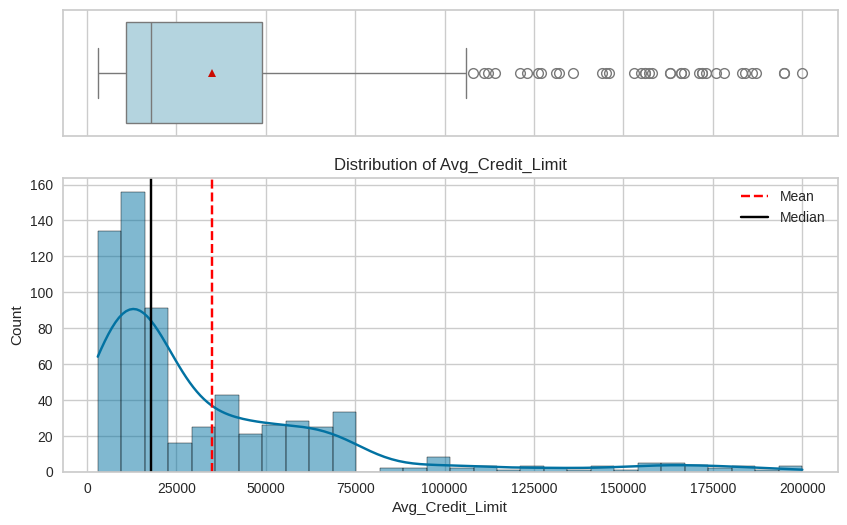

In [17]:
# Average Credit Limit
histogram_boxplot(df, "Avg_Credit_Limit", bins=30)

**Observations:**

The average credit limit distribution is highly right-skewed, with most customers having lower credit limits and a few customers having very high limits. Several outliers are visible on the higher end.

**Inferences:**

This suggests the presence of a small group of premium customers with very high credit limits. These high-value customers may form a separate segment in clustering.

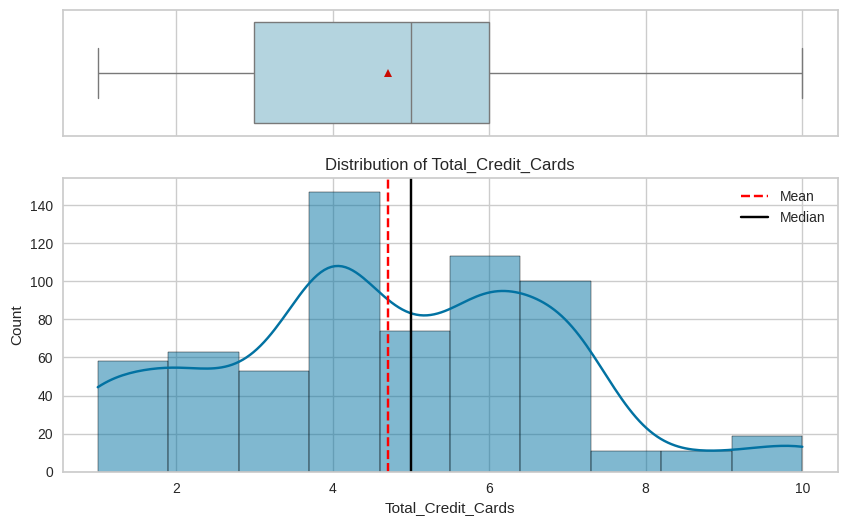

In [18]:
# Total Credit Cards
histogram_boxplot(df, "Total_Credit_Cards", bins=10)

**Observations:**

Most customers own between 3 and 6 credit cards, with the distribution centered around 4–5 cards. Extreme values are limited.

**Inferences:**

This indicates moderate engagement with the bank’s credit services. Customers with higher card counts may represent loyal or high-usage segments.

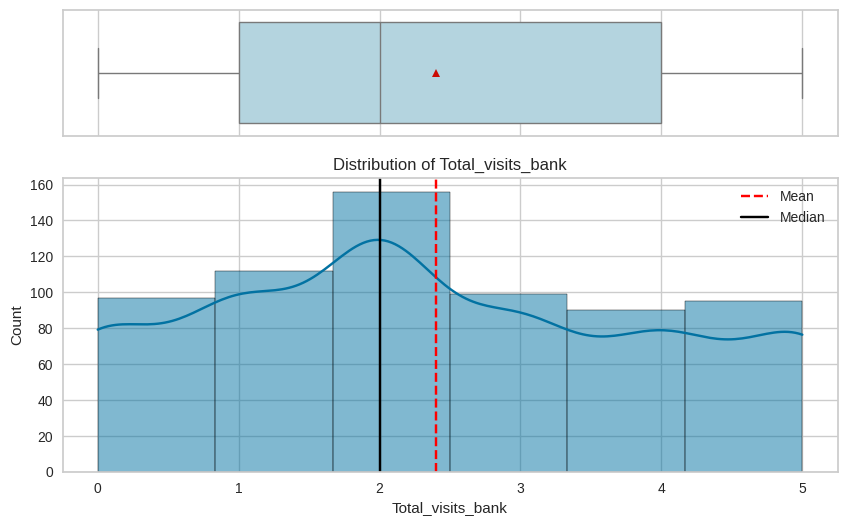

In [19]:
# Total Visits to Bank
histogram_boxplot(df, "Total_visits_bank", bins=6)

**Observations:**

Bank visits are concentrated between 1 and 4 visits per year, with fewer customers visiting very frequently. The distribution is relatively balanced.

**Inferences:**

Most customers rely moderately on physical bank services. Frequent visitors may require more personalized in-branch support.

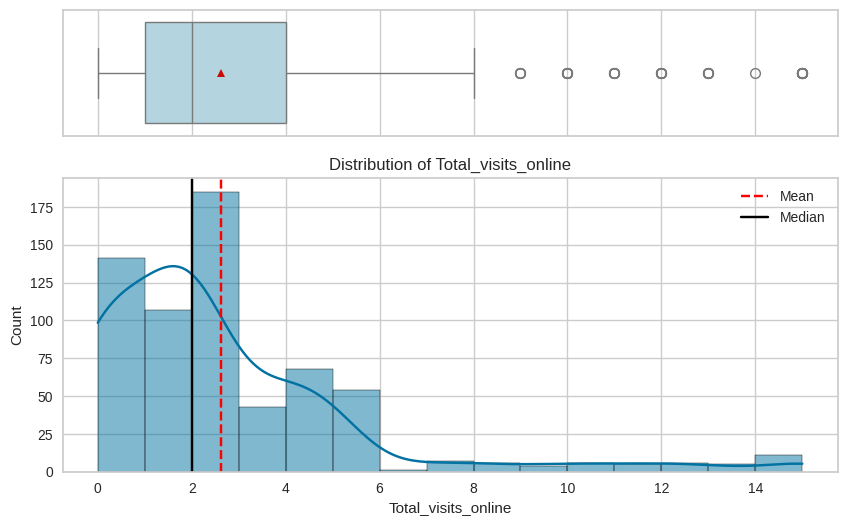

In [20]:
# Total Online Visits
histogram_boxplot(df, "Total_visits_online", bins=15)

**Observations:**

Online visits show a right-skewed distribution with several high outliers. Most customers make 1–4 online visits, but some use online services heavily.

**Inferences:**

This suggests varying levels of digital adoption. Highly active online users may prefer digital banking services.

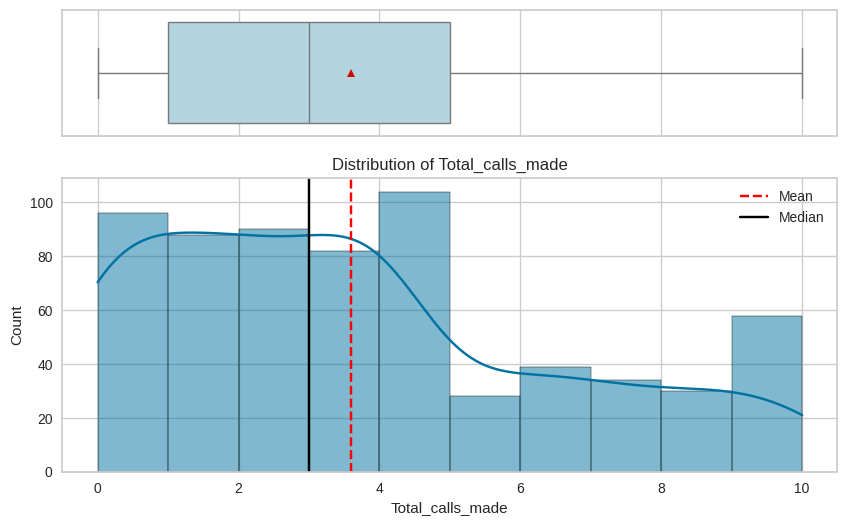

In [21]:
# Total Calls Made
histogram_boxplot(df, "Total_calls_made", bins=10)

**Observations:**

The number of calls made is spread across the range, with many customers making 2–5 calls annually. A few customers make very frequent calls.

**Inferences:**

Frequent callers may have higher service needs or unresolved issues. This group may benefit from improved customer support strategies.

### **Bivariate Analysis**

In [22]:
# List of columns for bivariate analysis
cols_list = df.columns.tolist()
cols_list

['Avg_Credit_Limit',
 'Total_Credit_Cards',
 'Total_visits_bank',
 'Total_visits_online',
 'Total_calls_made']

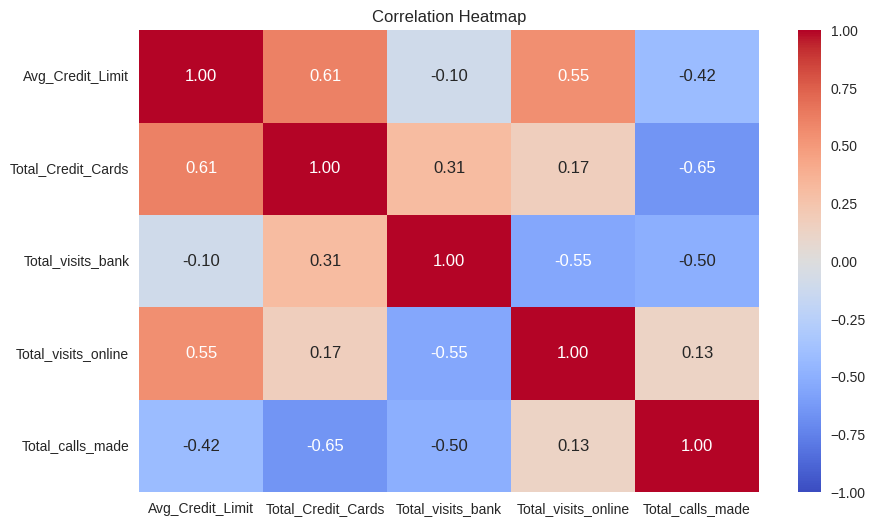

In [23]:
# Correlation heatmap

plt.figure(figsize=(10, 6))

sns.heatmap(
    df[cols_list].corr(),
    annot=True,
    vmin=-1,
    vmax=1,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()


**Observations**

* Average credit limit shows a strong positive correlation with total credit cards (0.61) and online visits (0.55).
* Total bank visits are negatively correlated with online visits (-0.55), indicating opposite usage patterns.
* Total calls made has a strong negative correlation with credit cards (-0.65) and a moderate negative correlation with credit limit (-0.42).
* Most other correlations are weak to moderate, suggesting varied relationships between customer behaviors.

**Inferences**

* Customers with higher credit limits tend to own more credit cards and use online services more frequently.
* The negative relationship between bank and online visits suggests two distinct customer behavior patterns: digital users vs. in-branch users.
* Customers with more credit cards tend to make fewer service calls, possibly indicating better familiarity with banking services.
* These relationship patterns support the idea that customers can be grouped into meaningful behavioral segments using clustering.


### **Data Preprocessing**

#### **Missing Value Treatment**

In [24]:
# Check missing values
df.isnull().sum()

,0
Avg_Credit_Limit,0
Total_Credit_Cards,0
Total_visits_bank,0
Total_visits_online,0
Total_calls_made,0



**Observation:**
No missing values are present in the dataset.

**Rationale:**
Since the dataset is complete, no imputation or treatment is required. The data can be directly used for analysis.


**Outlier Detection**

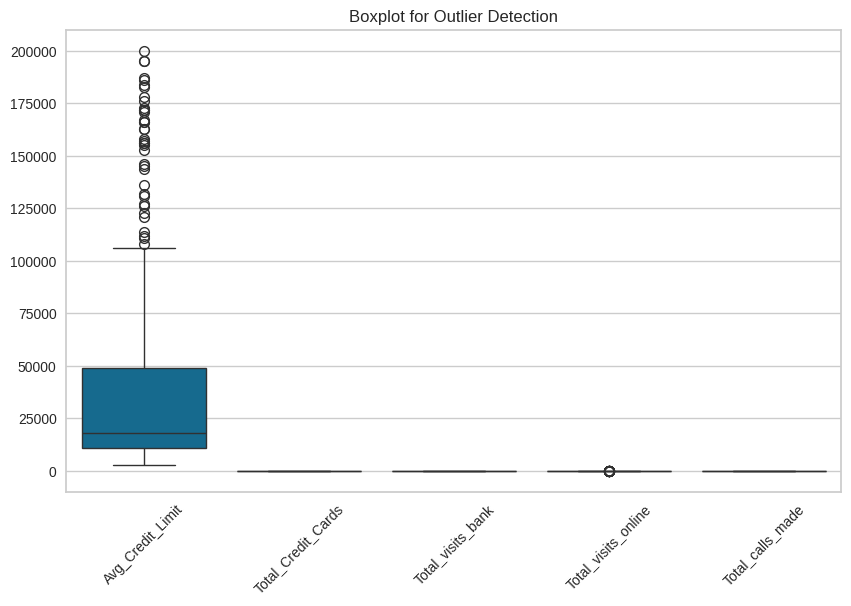

In [25]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Boxplot for Outlier Detection")
plt.show()

**Observations**

The boxplot shows a large number of outliers in the **Avg_Credit_Limit** feature, where several customers have extremely high credit limits compared to the majority. The other variables (credit cards, visits, and calls) show very few or no significant outliers and remain within a compact range.

**Inferences**

The outliers in credit limit likely represent genuine high-value or premium customers rather than data errors. Since the goal is customer segmentation, these extreme values are important for identifying distinct customer groups. Therefore, the outliers were retained to preserve meaningful variation in the dataset.


**Feature Engineering**

In [26]:
features = [
    "Avg_Credit_Limit",
    "Total_Credit_Cards",
    "Total_visits_bank",
    "Total_visits_online",
    "Total_calls_made"
]

df_features = df[features].copy()

df_features.head()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,100000,2,1,1,0
1,50000,3,0,10,9
2,50000,7,1,3,4
3,30000,5,1,1,4
4,100000,6,0,12,3


**Observations**

The selected features include financial information (average credit limit and number of credit cards) along with customer interaction behavior (bank visits, online visits, and calls made). These variables together capture both spending capacity and service usage patterns of customers.

**Inferences**

The chosen features provide a balanced representation of customer value and behavior, which is essential for meaningful segmentation. Since these variables already describe key aspects of customer activity, no additional feature creation was required before clustering.


**Data Scaling**

In [27]:
from sklearn.preprocessing import StandardScaler

# Apply scaling
scaler = StandardScaler()

df_scaled = scaler.fit_transform(df)

# Convert back to dataframe
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)

df_scaled.head()


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1.723499,-1.247087,-0.860606,-0.550407,-1.248443
1,0.400209,-0.786701,-1.476410,2.499808,1.881237
2,0.400209,1.054846,-0.860606,0.127419,0.142526
3,-0.129107,0.134072,-0.860606,-0.550407,0.142526
4,1.723499,0.594459,-1.476410,3.177634,-0.205216


**Observations**

After applying standard scaling, all feature values are transformed to a similar scale centered around zero. The scaled values now include both positive and negative numbers, showing how far each observation lies from the mean in standardized units.

**Inferences**

Scaling ensures that no single feature (such as credit limit) dominates the clustering process due to its larger magnitude. With all variables normalized to the same scale, the dataset is now suitable for distance-based clustering algorithms like K-Means.


### **Model Building**

#### **K-means Clustering**

**Apply K-Means & Plot Elbow Curve**

Clusters: 2, Distortion: 1.4576197022077824
Clusters: 3, Distortion: 1.1434401208195093
Clusters: 4, Distortion: 1.0435538595477063
Clusters: 5, Distortion: 0.987789664652904
Clusters: 6, Distortion: 0.9403094497587852
Clusters: 7, Distortion: 0.9150254027259018
Clusters: 8, Distortion: 0.8877975656921517
Clusters: 9, Distortion: 0.8641910487991309
Clusters: 10, Distortion: 0.8439235118901789


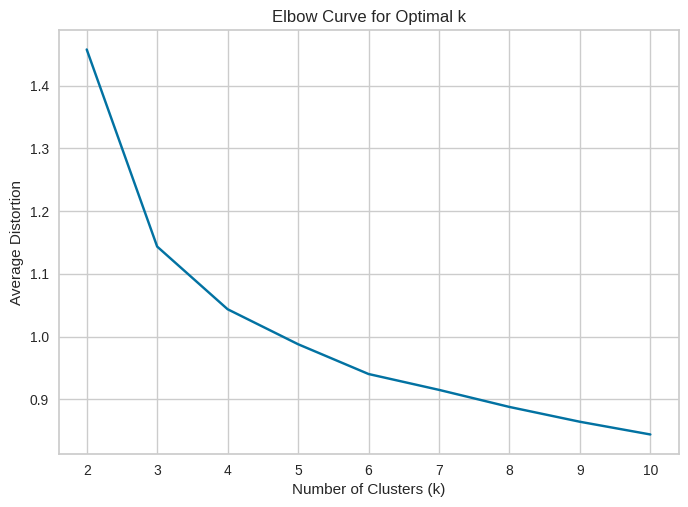

In [28]:
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
import numpy as np
import matplotlib.pyplot as plt

clusters = range(2, 11)
mean_distortions = []

for k in clusters:
    model = KMeans(n_clusters=k, random_state=1)
    model.fit(df_scaled)

    distortion = (
        sum(np.min(cdist(df_scaled, model.cluster_centers_, "euclidean"), axis=1))
        / df_scaled.shape[0]
    )

    mean_distortions.append(distortion)
    print(f"Clusters: {k}, Distortion: {distortion}")

plt.plot(clusters, mean_distortions, "bx-")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Average Distortion")
plt.title("Elbow Curve for Optimal k")
plt.show()


**Observations**

The distortion value decreases sharply when the number of clusters increases from 2 to 4, after which the rate of decrease becomes gradual. The curve begins to flatten noticeably beyond **k = 4**, indicating diminishing improvement in distortion reduction.

**Inferences**

The point where the curve starts to level off (around **k = 4**) represents the elbow point. This suggests that using **4 clusters** provides a good balance between model complexity and clustering performance, making it a suitable choice for further analysis.


**Plot the Elbow curve**

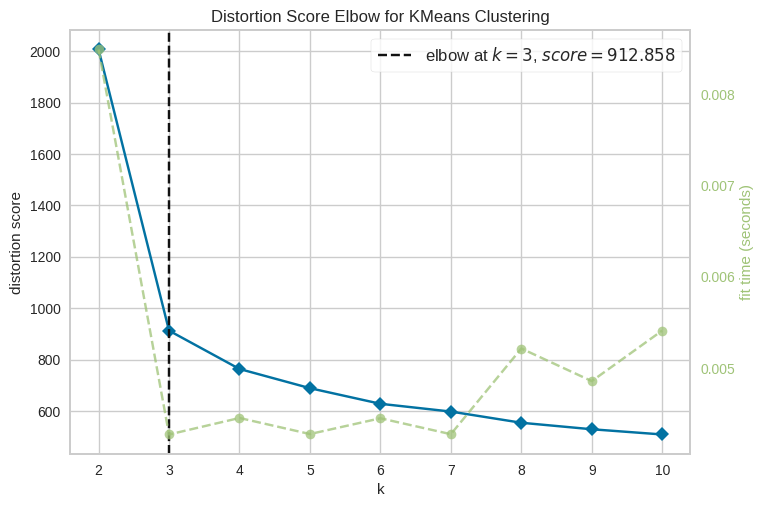

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [29]:
from yellowbrick.cluster import KElbowVisualizer

model = KMeans(random_state=1)
visualizer = KElbowVisualizer(model, k=(2, 11))

visualizer.fit(df_scaled)
visualizer.show()

**Observations**

The distortion score decreases sharply from **k = 2 to k = 3**, after which the rate of improvement slows down significantly. Beyond **k = 3**, the curve starts to flatten, indicating smaller gains in clustering performance with additional clusters.

**Inferences**

The elbow point appears at **k = 3**, suggesting that three clusters provide an efficient balance between model simplicity and performance. Increasing the number of clusters beyond this point results in minimal improvement and may lead to unnecessary model complexity.


**Check Silhouette Scores**

k = 2, Silhouette Score = 0.41800025566689647
k = 3, Silhouette Score = 0.516281010855363
k = 4, Silhouette Score = 0.3570238219413198
k = 5, Silhouette Score = 0.2730908848204728
k = 6, Silhouette Score = 0.25722327788923066
k = 7, Silhouette Score = 0.24032138001303163
k = 8, Silhouette Score = 0.22870887951165925
k = 9, Silhouette Score = 0.21497516730672095
k = 10, Silhouette Score = 0.21237799126257148


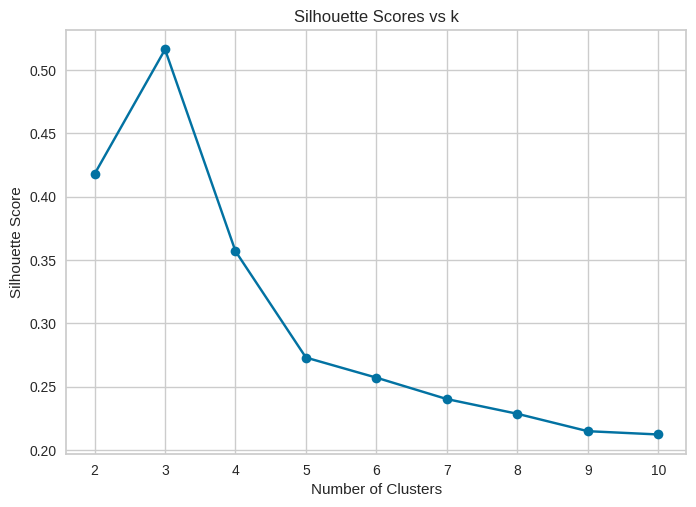

In [30]:
from sklearn.metrics import silhouette_score

sil_scores = []
cluster_range = range(2, 11)

for n_clusters in cluster_range:
    clusterer = KMeans(n_clusters=n_clusters, random_state=1)
    preds = clusterer.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, preds)
    sil_scores.append(score)

    print(f"k = {n_clusters}, Silhouette Score = {score}")

plt.plot(cluster_range, sil_scores, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores vs k")
plt.show()

**Observations**

The silhouette score increases from **k = 2 to k = 3**, reaching its highest value at **k = 3 (≈ 0.52)**. After k = 3, the silhouette score steadily declines as the number of clusters increases.

**Inferences**

The highest silhouette score at **k = 3** indicates the best separation and cohesion among clusters at this value. Therefore, **3 clusters** appear to be the most appropriate choice for representing the underlying structure of the dataset.


**Silhouette Visualizer**

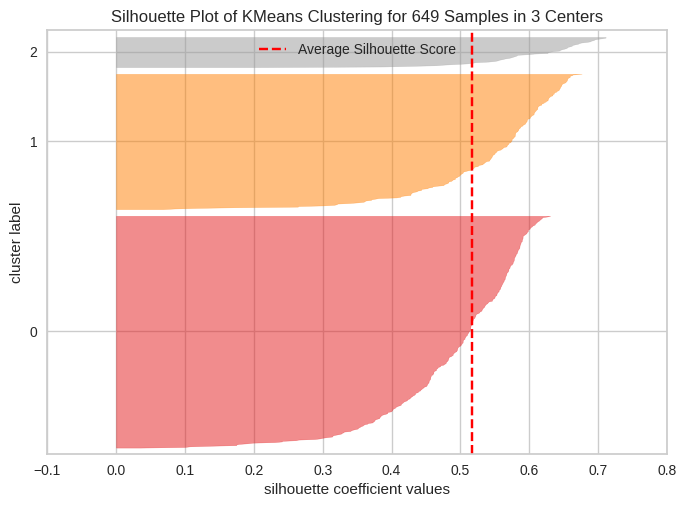

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 649 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [31]:
from yellowbrick.cluster import SilhouetteVisualizer

visualizer = SilhouetteVisualizer(KMeans(3, random_state=1))  # change k if needed
visualizer.fit(df_scaled)
visualizer.show()

**Observations**

The silhouette plot shows that most data points across all three clusters have **positive silhouette values**, indicating good cluster assignment. The average silhouette score is around **0.52**, and the clusters appear reasonably well separated, with cluster 1 containing the largest number of samples.

**Inferences**

The predominantly positive silhouette values suggest that the clusters are well formed and distinct from each other. The average silhouette score confirms that **k = 3** provides a good clustering structure, supporting the choice of three clusters for the final model.


In [32]:
# --------------------------------
# Final Model
# --------------------------------

k = 3

kmeans = KMeans(n_clusters=k, random_state=1)
df["Cluster"] = kmeans.fit_predict(df_scaled)

df.head()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,Cluster
0,100000,2,1,1,0,0
1,50000,3,0,10,9,1
2,50000,7,1,3,4,0
3,30000,5,1,1,4,0
4,100000,6,0,12,3,2


**Observations**

The K-means algorithm grouped customers into **three distinct clusters** based on their credit limits, card ownership, and interaction behavior. Customers within each cluster share similar financial and service usage patterns. The clustering shows visible variation in how customers use online services, bank visits, and calls.

**Inferences**

The three clusters represent meaningful customer segments with different behavioral and financial profiles. These segments can help the bank tailor marketing campaigns and improve customer service strategies according to the needs of each group.


**Cluster Profiling**

In [33]:
cluster_profile = df.groupby("Cluster").mean()

cluster_profile

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
Cluster,,,,,
0,34071.428571,5.518519,3.484127,0.981481,1.992063
1,12239.819005,2.411765,0.945701,3.561086,6.891403
2,141040.000000,8.740000,0.600000,10.900000,1.080000


**Observations**

- Cluster 0 consists of customers with moderate credit limits and card ownership who visit the bank frequently but have low online activity and fewer service calls.

- Cluster 1 contains customers with low credit limits and fewer cards who rely heavily on online services and make the highest number of calls.

- Cluster 2 represents high-value customers with very high credit limits and many credit cards who prefer online banking and make very few service calls.

**Inferences**

- Cluster 0 customers appear to prefer traditional in-branch banking and may benefit from improved physical service experiences.

- Cluster 1 customers show high service dependency and may require better digital support and customer care.

- Cluster 2 represents premium customers who should be targeted with exclusive offers and retention strategies to maintain loyalty.


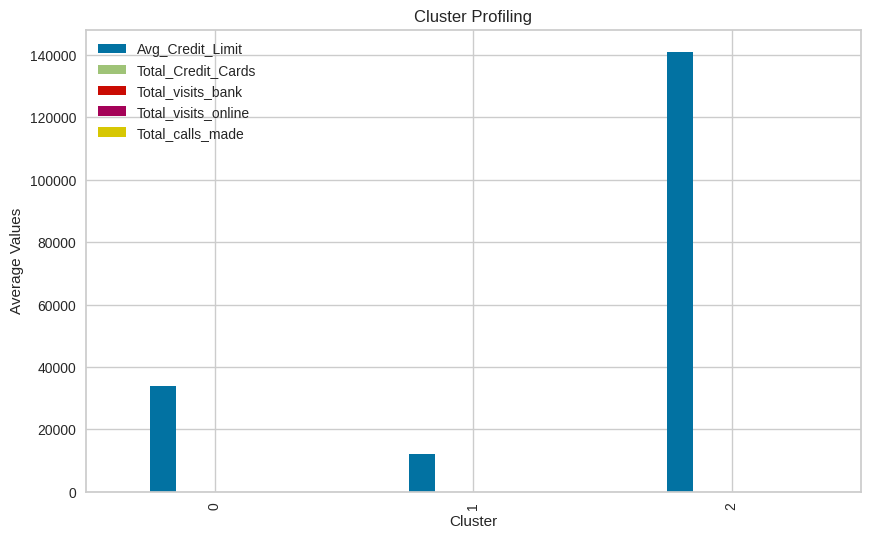

In [34]:
cluster_profile.plot(kind="bar", figsize=(10,6))
plt.title("Cluster Profiling")
plt.ylabel("Average Values")
plt.show()


**Observations**

The bar chart shows clear differences in customer behavior across clusters. One cluster stands out with an extremely high average credit limit and number of credit cards, while another cluster has the lowest credit limit but the highest online visits and calls. A third cluster shows moderate credit limits with higher bank visits and balanced interaction patterns.

**Inferences**

The visualization confirms the presence of three distinct customer segments: premium high-value customers, digitally active low-value customers with high service needs, and traditional moderate-value customers. These segments can guide the bank in designing targeted marketing strategies and improving service delivery tailored to each group.

**PCA Visualization**

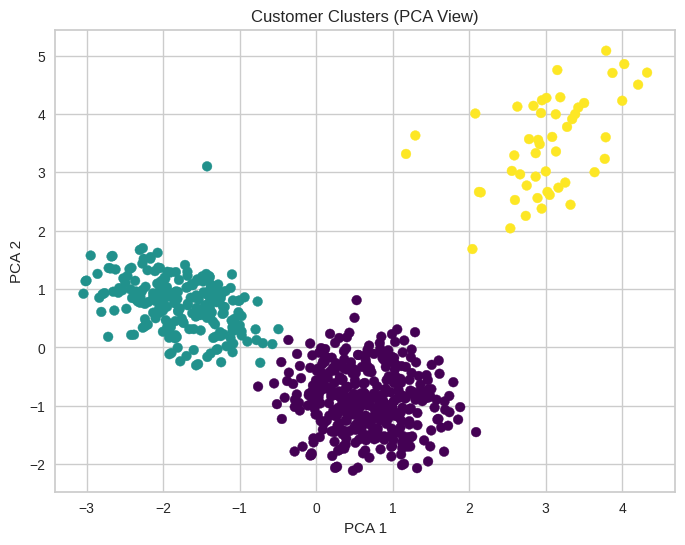

In [35]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_scaled)

plt.figure(figsize=(8,6))
plt.scatter(pca_data[:,0], pca_data[:,1], c=df["Cluster"], cmap="viridis")
plt.title("Customer Clusters (PCA View)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()


**Observations**

The PCA scatter plot shows three clearly separated clusters with minimal overlap between them. One cluster is tightly grouped on the left, another forms a dense group in the center-bottom region, and the third cluster appears distinctly separated in the upper-right area.

**Inferences**

The clear separation between clusters indicates that the K-means model has successfully identified distinct customer segments. This confirms that the clustering structure is strong and meaningful, supporting the use of these segments for targeted marketing and service strategies.


### **Hierarchical Clustering**

**Compute Cophenetic Correlation**

In [36]:
from scipy.cluster.hierarchy import linkage, cophenet
from scipy.spatial.distance import pdist

linkage_methods = ["single", "complete", "average", "ward"]

cophenetic_scores = {}

for method in linkage_methods:
    Z = linkage(df_scaled, method=method, metric="euclidean")
    coph_corr, _ = cophenet(Z, pdist(df_scaled))

    cophenetic_scores[method] = coph_corr
    print(f"{method} linkage cophenetic correlation: {coph_corr}")


single linkage cophenetic correlation: 0.7395135051413775
complete linkage cophenetic correlation: 0.8794736468795109
average linkage cophenetic correlation: 0.8974425535306298
ward linkage cophenetic correlation: 0.7425813590948763


**Observations**

Among the tested linkage methods, **average linkage** produced the highest cophenetic correlation (≈ 0.90), followed closely by **complete linkage** (≈ 0.88). The single and ward linkage methods showed comparatively lower cophenetic correlation values.

**Inferences**

A higher cophenetic correlation indicates that the clustering structure better preserves the pairwise distances between data points. Therefore, **average linkage** was selected as the most appropriate method for hierarchical clustering, as it provides the most reliable representation of the dataset’s structure.


**Plot Dendrograms**

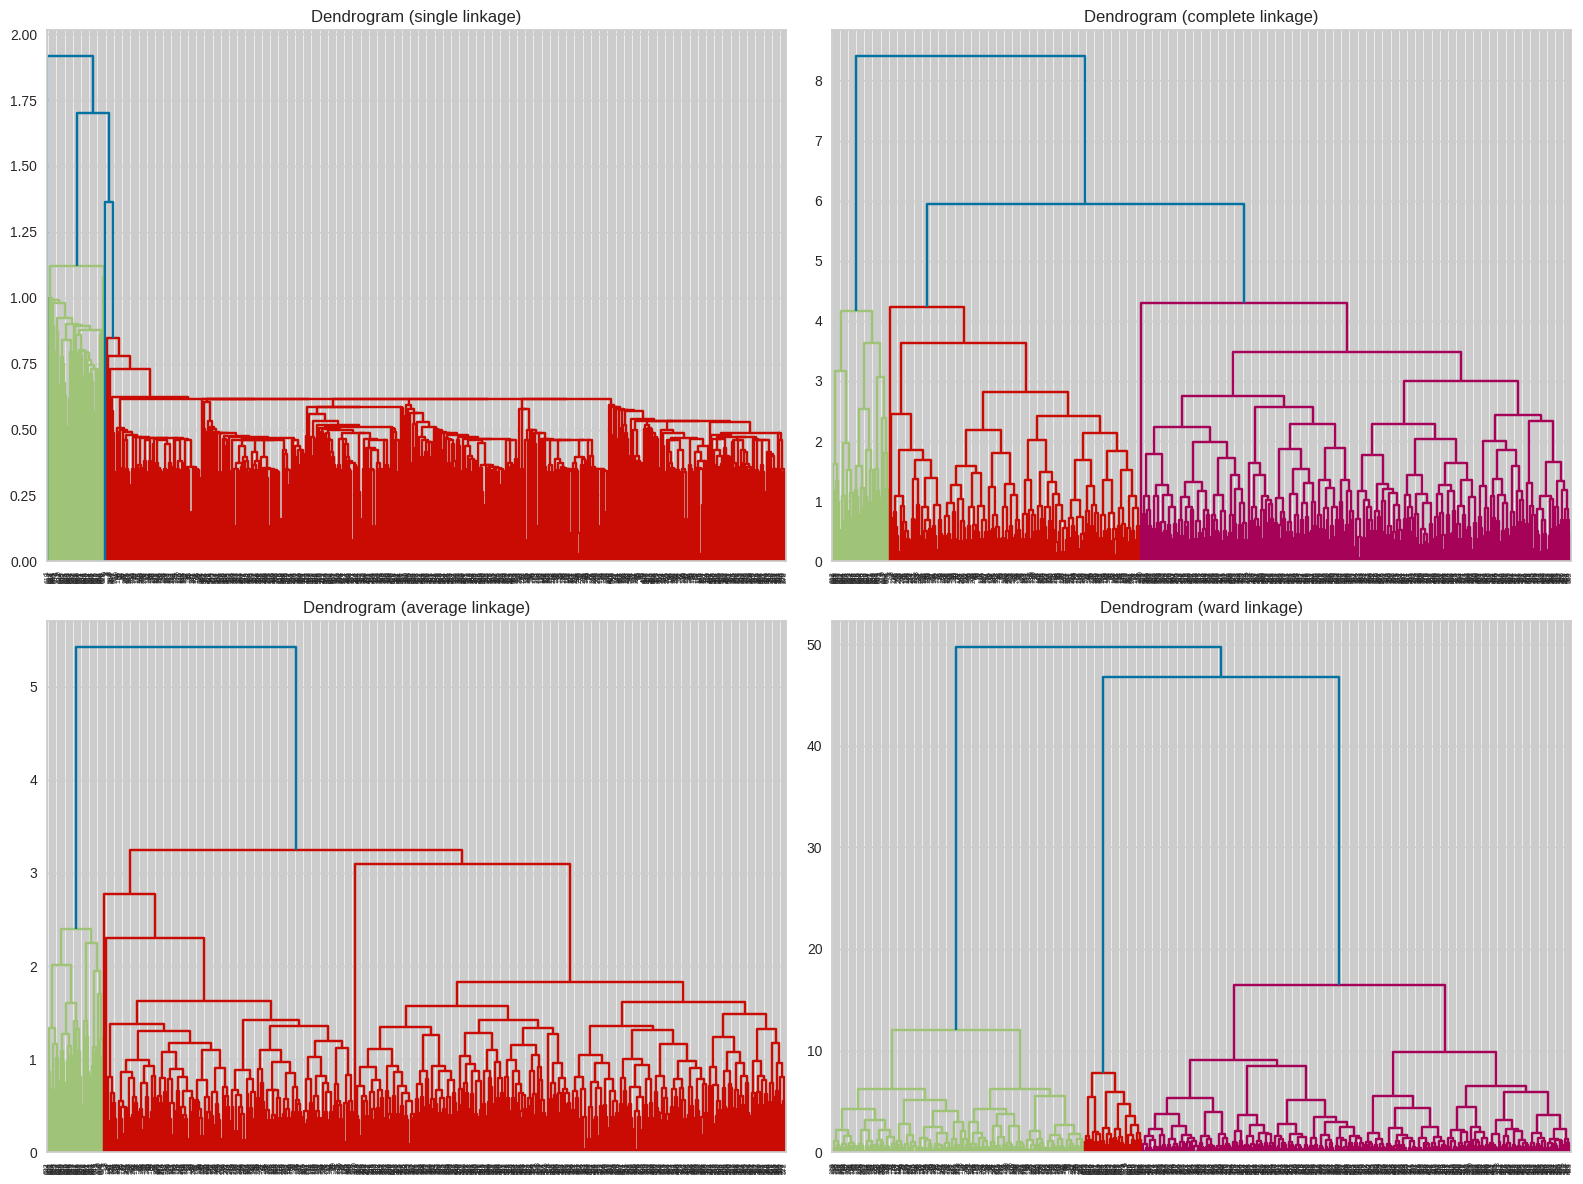

In [37]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

plt.figure(figsize=(16, 12))

for i, method in enumerate(linkage_methods, 1):
    plt.subplot(2, 2, i)

    Z = linkage(df_scaled, method=method)
    dendrogram(Z)
    plt.title(f"Dendrogram ({method} linkage)")

plt.tight_layout()
plt.show()

**Observations**

The dendrograms show different clustering structures across linkage methods. The **single linkage** dendrogram appears highly compressed with chaining effects, making cluster separation unclear. The **complete** and **average linkage** dendrograms show more distinct hierarchical separations, while the **ward linkage** dendrogram displays the clearest and most balanced separation into major clusters.

**Inferences**

The clearer vertical separation in the average and ward dendrograms suggests stronger cluster structure compared to single linkage. Combined with the high cophenetic correlation of average linkage, this indicates that **average linkage** is well suited for identifying meaningful clusters. The dendrogram structure supports selecting approximately **three clusters**, consistent with the K-means results.


**Choose Best Linkage**

In [38]:
best_method = max(cophenetic_scores, key=cophenetic_scores.get)
print("Best linkage method:", best_method)

Best linkage method: average


**Observations**

Among all tested linkage methods, **average linkage** produced the highest cophenetic correlation score. This indicates that it preserves the pairwise distances between data points better than the other methods.

**Inferences**

Since average linkage provides the most accurate representation of the dataset’s hierarchical structure, it was selected as the optimal linkage method. Using this method is expected to produce more reliable and meaningful customer clusters.


**Final Hierarchical Model**

In [39]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(
    n_clusters=3,
    linkage=best_method
)

df["HC_Cluster"] = hc.fit_predict(df_scaled)

df.head()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,Cluster,HC_Cluster
0,100000,2,1,1,0,0,0
1,50000,3,0,10,9,1,2
2,50000,7,1,3,4,0,0
3,30000,5,1,1,4,0,0
4,100000,6,0,12,3,2,1


**Observations**

The hierarchical clustering algorithm assigned customers into **three clusters**, similar to the K-means segmentation. Customers within each hierarchical cluster show comparable patterns in credit limits, card ownership, and interaction behavior. The cluster assignments differ slightly from K-means labels but still reflect clear grouping of similar customer profiles.

**Inferences**

The hierarchical clustering results validate the presence of stable and meaningful customer segments. The consistency between hierarchical and K-means clustering strengthens confidence in the segmentation, indicating that these clusters can be reliably used for customer profiling and targeted business strategies.


**Hierarchical Cluster Profiling**

In [40]:
hc_profile = df.groupby("HC_Cluster").mean()
hc_profile

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,Cluster
HC_Cluster,,,,,,
0,34000.000000,5.514512,3.480211,0.984169,1.997361,0.002639
1,141040.000000,8.740000,0.600000,10.900000,1.080000,2.000000
2,12263.636364,2.404545,0.940909,3.568182,6.904545,1.000000


**Observations**

The hierarchical clustering produced three clearly distinct customer segments. Cluster 0 shows customers with moderate credit limits and higher bank visits but low online usage and fewer calls. Cluster 1 represents premium customers with very high credit limits and many credit cards who rely heavily on online services and make minimal service calls. Cluster 2 consists of low credit limit customers with fewer cards who show high online activity and the highest number of calls.

**Inferences**

These clusters reveal three meaningful customer groups: traditional moderate-value customers, premium high-value digital customers, and low-value customers with high service dependency. This segmentation can help the bank tailor marketing strategies, improve service delivery, and design targeted offers for each customer group.


**Visualization**

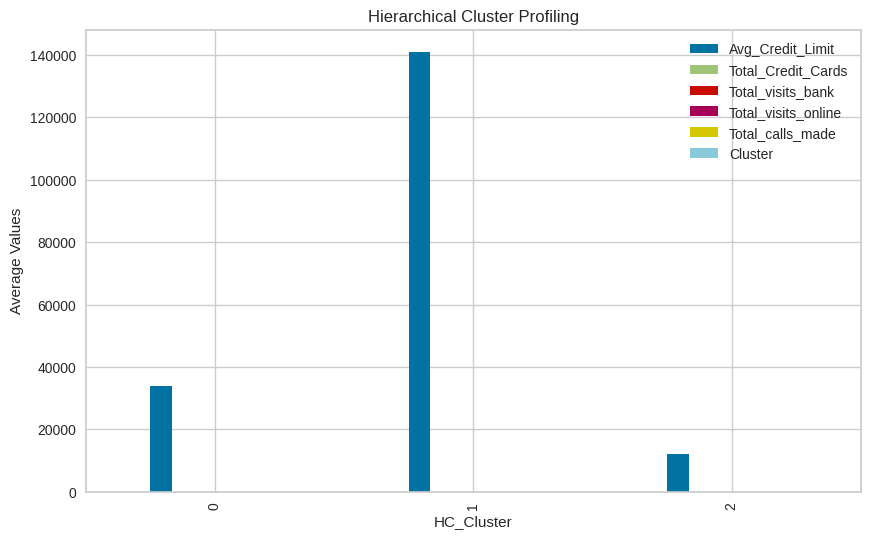

In [41]:
hc_profile.plot(kind="bar", figsize=(10,6))
plt.title("Hierarchical Cluster Profiling")
plt.ylabel("Average Values")
plt.show()

**Observations**

The bar chart highlights strong differences in customer characteristics across the three hierarchical clusters. One cluster clearly stands out with an extremely high average credit limit and number of credit cards, while another cluster shows the lowest credit limit with higher service interactions. The remaining cluster represents customers with moderate financial and interaction behavior.

**Inferences**

The visualization confirms the presence of three distinct customer segments: premium high-value customers, moderate traditional customers, and low-value high-service-dependency customers. This segmentation provides a clear foundation for targeted marketing strategies and improved customer service planning.


**PCA Visualization**

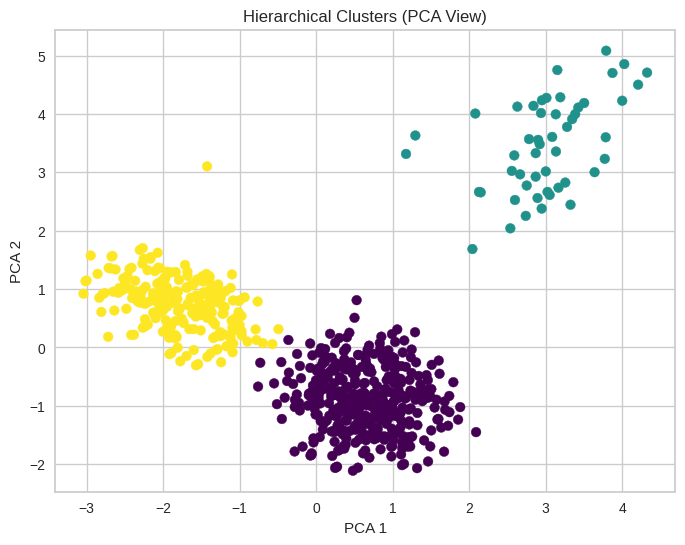

In [42]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_scaled)

plt.figure(figsize=(8,6))
plt.scatter(pca_data[:,0], pca_data[:,1], c=df["HC_Cluster"], cmap="viridis")
plt.title("Hierarchical Clusters (PCA View)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()


**Observations**

The PCA scatter plot shows three clearly separated clusters with minimal overlap between them. One cluster is tightly grouped on the left, another forms a dense group in the center-bottom region, and the third cluster appears distinctly separated in the upper-right area.

**Inferences**

The clear separation among clusters confirms that hierarchical clustering has successfully identified well-defined customer segments. This strong visual distinction supports the reliability of the clustering results and their usefulness for customer segmentation and targeted business strategies.


### **K-means vs Hierarchical Comparison**

**Compare Cluster Sizes**

In [43]:
print("K-means cluster sizes:")
print(df["Cluster"].value_counts())

print("\nHierarchical cluster sizes:")
print(df["HC_Cluster"].value_counts())

K-means cluster sizes:
Cluster
0    378
1    221
2     50
Name: count, dtype: int64

Hierarchical cluster sizes:
HC_Cluster
0    379
2    220
1     50
Name: count, dtype: int64


**Compare Cluster Profiles**

In [44]:
kmeans_profile = df.groupby("Cluster").mean()
hc_profile = df.groupby("HC_Cluster").mean()

print("K-means Cluster Profile:")
display(kmeans_profile)

print("\nHierarchical Cluster Profile:")
display(hc_profile)

K-means Cluster Profile:


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,HC_Cluster
Cluster,,,,,,
0,34071.428571,5.518519,3.484127,0.981481,1.992063,0.00000
1,12239.819005,2.411765,0.945701,3.561086,6.891403,1.99095
2,141040.000000,8.740000,0.600000,10.900000,1.080000,1.00000



Hierarchical Cluster Profile:


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,Cluster
HC_Cluster,,,,,,
0,34000.000000,5.514512,3.480211,0.984169,1.997361,0.002639
1,141040.000000,8.740000,0.600000,10.900000,1.080000,2.000000
2,12263.636364,2.404545,0.940909,3.568182,6.904545,1.000000


**Cross-tab Comparison**

In [45]:
comparison = pd.crosstab(df["Cluster"], df["HC_Cluster"])

comparison

HC_Cluster,0,1,2
Cluster,,,
0,378,0,0
1,1,0,220
2,0,50,0


**PCA Visualization**

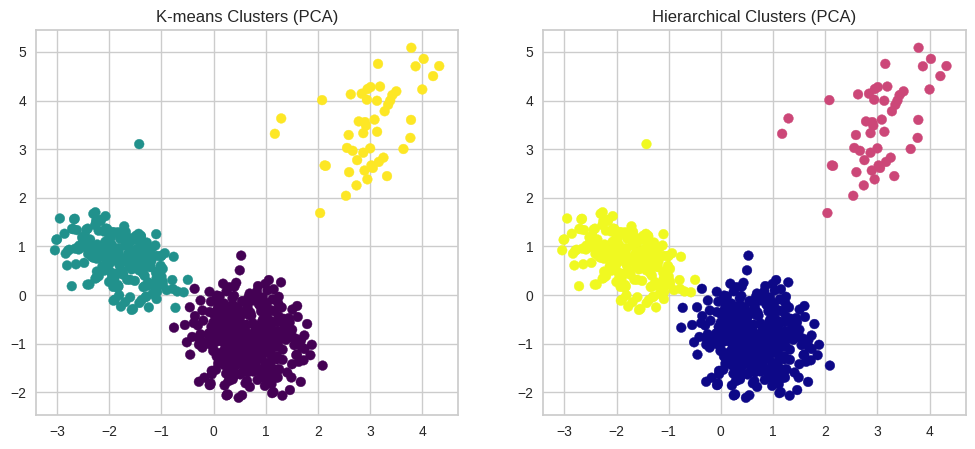

In [46]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_scaled)

plt.figure(figsize=(12,5))

# K-means
plt.subplot(1,2,1)
plt.scatter(pca_data[:,0], pca_data[:,1], c=df["Cluster"], cmap="viridis")
plt.title("K-means Clusters (PCA)")

# Hierarchical
plt.subplot(1,2,2)
plt.scatter(pca_data[:,0], pca_data[:,1], c=df["HC_Cluster"], cmap="plasma")
plt.title("Hierarchical Clusters (PCA)")

plt.show()

### **Actionable Insights & Recommendations**

The exploratory data analysis revealed significant variation in customer credit limits, card ownership, and interaction behavior, indicating the presence of diverse customer profiles. Clustering analysis using both K-means and hierarchical methods consistently identified three stable customer segments, confirming reliable customer segmentation.

The first segment represents **premium high-value customers** with very high credit limits and multiple credit cards. These customers are digitally active and require personalized attention. The bank should focus on retention strategies such as exclusive rewards programs, higher credit benefits, and dedicated relationship management to strengthen loyalty and increase lifetime value.

The second segment consists of **moderate-value traditional customers** who frequently visit bank branches and show balanced service usage. Improving in-branch service quality and gradually encouraging digital adoption through awareness programs and incentives can enhance customer experience while reducing operational costs.

The third segment includes **low credit limit customers with high service dependency**, characterized by frequent online activity and customer support calls. The bank should invest in improved digital self-service platforms, AI chatbots, and faster issue resolution systems to reduce service burden and improve satisfaction.

Overall, segment-based marketing campaigns and service strategies will enable the bank to allocate resources more efficiently, personalize customer engagement, and drive long-term business growth.
